In [24]:
import cv2
import os
import numpy as np
from PIL import Image
import subprocess, json, csv, sys
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import imageio
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.functional import softmax
from torchvision.transforms.functional import to_pil_image

from sklearn.model_selection import train_test_split  # handy splitting tool
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support


In [4]:
file_path = "/Users/jgrui/Desktop" # Replace with your desired directory path

In [5]:


def extract_frames(video_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(f"{out_dir}/{idx:06d}.png", gray)
        idx += 1
    cap.release()


In [6]:


def get_clip(center_time, frame_dir, fps=50, window=4):
    center_frame = int(center_time * fps)
    frames = []
    for offset in range(-window, window+1):
        idx = max(0, center_frame + offset)
        img = Image.open(f"{frame_dir}/{idx:06d}.png")
        frames.append(np.array(img))
    return np.stack(frames, axis=0)  # shape: (T, H, W)


In [7]:
cap = cv2.VideoCapture(f"{file_path}/USC-TIMIT/MRI/Data/M1/avi/usctimit_mri_m1_001_005.avi")
fps = cap.get(cv2.CAP_PROP_FPS)
nframes = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = nframes / fps if fps>0 else None
print(fps, nframes, duration)
cap.release()

23.18 501 21.613459879206214


In [8]:
# save as collect_video_metadata.py

def ffprobe_info(path):
    try:
        cmd = [
            "ffprobe", "-v", "error", "-select_streams", "v:0",
            "-show_entries", "stream=avg_frame_rate,nb_frames,width,height,duration",
            "-of", "json", str(path)
        ]
        out = subprocess.check_output(cmd, stderr=subprocess.DEVNULL).decode()
        j = json.loads(out)
        s = j['streams'][0]
        # avg_frame_rate might be like "2318/100"
        afr = s.get('avg_frame_rate', '0/1')
        num, den = afr.split('/')
        fps = float(num)/float(den) if float(den)!=0 else 0.0
        nb = int(s.get('nb_frames')) if s.get('nb_frames') and s.get('nb_frames').isdigit() else None
        dur = float(s.get('duration')) if s.get('duration') else (nb/fps if nb and fps>0 else None)
        return fps, nb, dur, s.get('width'), s.get('height')
    except Exception:
        return None

def opencv_info(path):
    try:
        import cv2
        cap = cv2.VideoCapture(str(path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        nb = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        dur = nb / fps if fps>0 else None
        w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()
        return fps, nb, dur, w, h
    except Exception:
        return None

root = Path(f"{file_path}/USC-TIMIT/MRI/Data/M1/avi")
outcsv = Path("video_metadata.csv")
with outcsv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filepath","fps","nframes","duration","width","height","speaker","sentence_id"])
    for p in root.rglob("*.avi"):
        info = ffprobe_info(p)
        if not info:
            info = opencv_info(p)
        if not info:
            print("Skipping (no info):", p)
            continue
        fps, nb, dur, w, h = info
        # attempt to infer speaker/sentence from path (adjust to your layout)
        parts = p.parts
        speaker = parts[-3] if len(parts)>=3 else ""
        sentence_id = parts[-2] if len(parts)>=2 else ""
        writer.writerow([str(p), fps, nb, dur, w, h, speaker, sentence_id])
print("Wrote:", outcsv)


Wrote: video_metadata.csv


In [12]:
# --- Transcript Reader -------------------------------------------------------

def load_transcript(path, keep_sil=False):
    entries = []

    with open(path, "r", encoding="utf-8") as f:
        reader = csv.reader(f)

        for line_num, row in enumerate(reader, start=1):
            if not row:
                continue

            # # --- DEBUG PRINT FOR LONG ROWS ---
            # if len(row) > 5:
            #     print("\n⚠️  Long row detected!")
            #     print(f"File: {path}")
            #     print(f"Line {line_num}: {row}")
            #     print(f"Columns: {len(row)}\n")

            # Trim extra columns
            if len(row) > 5:
                row = row[:5]

            # Pad missing
            while len(row) < 5:
                row.append("")

            start_str, end_str, ph, word, sent = row

            ph = ph.strip()
            word = word.strip() if word else ""
            sent = sent.strip() if sent else ""

            # Convert to floats
            try:
                start = float(start_str)
                end = float(end_str)
            except ValueError:
                continue

            if not keep_sil and ph.lower() == "sil":
                continue
            if ph == "":
                continue

            entries.append({
                "start": start,
                "end": end,
                "phoneme": ph,
                "word": word if word else None,
                "sentence": sent if sent else None
            })

    return entries



# --- Dataset Walker ----------------------------------------------------------

def load_speaker(root_path, speaker_id, keep_sil=False):
    """
    Loads all videos + transcripts + audio for one speaker (e.g., 'M1').

    Returns:
        {
            "001_005": {
                "avi":  "/.../avi/usctimit_mri_m1_001_005.avi",
                "wav":  "/.../wav/usctimit_mri_m1_001_005.wav",
                "transcript": [...]
            },
            ...
        }
    """
    speaker_path = os.path.join(root_path, speaker_id)

    avi_dir  = os.path.join(speaker_path, "avi")
    wav_dir  = os.path.join(speaker_path, "wav")
    trans_dir = os.path.join(speaker_path, "trans")

    speaker_data = {}

    # Look at all transcript files and use them as the anchor
    for fname in os.listdir(trans_dir):
        if fname.startswith(".") or not fname.endswith(".trans"):
            continue

        base = fname.replace(".trans", "")  # e.g. "usctimit_mri_m1_001_005"

        # Extract the file ID part (e.g. "001_005")
        parts = base.split("_")
        file_id = parts[-2] + "_" + parts[-1]

        trans_path = os.path.join(trans_dir, fname)

        # Expected video/audio names
        avi_path = os.path.join(avi_dir, base + ".avi")
        wav_path = os.path.join(wav_dir, base + ".wav")

        # Safety checks
        if not os.path.exists(avi_path):
            print(f"WARNING: Missing AVI for {base}")
        if not os.path.exists(wav_path):
            print(f"WARNING: Missing WAV for {base}")

        entries = load_transcript(trans_path, keep_sil=keep_sil)

        speaker_data[file_id] = {
            "avi": avi_path if os.path.exists(avi_path) else None,
            "wav": wav_path if os.path.exists(wav_path) else None,
            "transcript": entries
        }

    return speaker_data


def load_all_speakers(root_path, keep_sil=False):
    """
    Loads M1..Mn, F1..Fn automatically.
    Returns:
        {
            "M1": {...speaker_data...},
            "M2": {...},
            ...
            "F5": {...}
        }
    """
    dataset = {}

    for speaker_id in sorted(os.listdir(root_path)):
        speaker_dir = os.path.join(root_path, speaker_id)
        if not os.path.isdir(speaker_dir):
            continue

        # Only accept M1/M2/.../F5
        if not (speaker_id.startswith("M") or speaker_id.startswith("F")):
            continue

        print(f"Loading {speaker_id}...")
        dataset[speaker_id] = load_speaker(root_path, speaker_id, keep_sil=keep_sil)

    return dataset


In [13]:
root = f"{file_path}/USC-TIMIT/MRI/Data"   # contains M1/ M2/ ... F5/

all_data = load_all_speakers(root, keep_sil=False)

# Example: access data
print(all_data["M1"].keys())              # all utterances
print(all_data["M1"]["001_005"]["avi"])   # path to video
print(all_data["M1"]["001_005"]["transcript"][:3])   # first few transcript entries


Loading F1...
Loading F2...
Loading F3...
Loading F4...
Loading F5...
Loading M1...
Loading M2...
Loading M3...
Loading M4...
Loading M5...
dict_keys(['001_005', '006_010', '011_015', '016_020', '021_025', '026_030', '031_035', '036_040', '041_045', '046_050', '051_055', '056_060', '061_065', '066_070', '071_075', '076_080', '081_085', '086_090', '091_095', '096_100', '101_105', '106_110', '111_115', '116_120', '121_125', '126_130', '131_135', '136_140', '141_145', '146_150', '151_155', '156_160', '161_165', '166_170', '171_175', '176_180', '181_185', '186_190', '191_195', '196_200', '201_205', '206_210', '211_215', '216_220', '221_225', '226_230', '231_235', '236_240', '241_245', '246_250', '251_255', '256_260', '261_265', '266_270', '271_275', '276_280', '281_285', '286_290', '291_295', '296_300', '301_305', '306_310', '311_315', '316_320', '321_325', '326_330', '331_335', '336_340', '341_345', '346_350', '351_355', '356_360', '361_365', '366_370', '371_375', '376_380', '381_385', '3

In [14]:
FPS = 23.18

def phoneme_to_frame_range(start_sec, end_sec, fps=FPS):
    start_f = int(start_sec * fps)
    end_f   = int(end_sec * fps)
    return start_f, end_f


import cv2
import numpy as np

def load_video_frames(path, start_frame, end_frame):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        print(f"Could not open: {path}")
        return None

    frames = []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    for f in range(start_frame, end_frame + 1):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)   # MRI is grayscale
        frame = frame.astype(np.float32) / 255.0          # normalize
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return None

    return np.stack(frames)

def build_phoneme_dataset(all_data, fps=FPS, max_frames=5):
    samples = []

    for speaker_id, utts in all_data.items():
        print(f"Building samples for {speaker_id}...")

        for file_id, item in utts.items():
            avi = item["avi"]
            transcript = item["transcript"]

            if avi is None:
                continue

            for entry in transcript:
                ph = entry["phoneme"]
                start_sec = entry["start"]
                end_sec = entry["end"]

                start_f, end_f = phoneme_to_frame_range(start_sec, end_sec, fps)

                # Limit duration for easier training
                if end_f - start_f > max_frames:
                    end_f = start_f + max_frames

                frames = load_video_frames(avi, start_f, end_f)
                if frames is None:
                    continue

                samples.append({
                    "phoneme": ph,
                    "frames": frames,
                    "speaker": speaker_id,
                    "file": file_id
                })

    return samples


In [15]:
max_frames = 5
phoneme_data = build_phoneme_dataset(all_data)
print("Total samples:", len(phoneme_data))


Building samples for F1...
Building samples for F2...
Building samples for F3...
Building samples for F4...
Building samples for F5...
Building samples for M1...
Building samples for M2...
Building samples for M3...
Building samples for M4...
Building samples for M5...
Total samples: 132064


In [16]:


FPS = 23.18


def sec_to_frame(t, fps=FPS):
    return int(t * fps)


class MRIPhonemeDataset(Dataset):
    def __init__(self, all_data, max_frames=5, resize=128, include_sil=False):
        self.samples = []
        self.max_frames = max_frames
        self.resize = resize

        for speaker, utts in all_data.items():
            for file_id, item in utts.items():

                if item["avi"] is None:
                    continue

                avi_path = item["avi"]
                transcript = item["transcript"]

                for t in transcript:
                    ph = t["phoneme"]

                    if (not include_sil) and ph.lower() == "sil":
                        continue

                    start_f = sec_to_frame(t["start"])
                    end_f   = sec_to_frame(t["end"])

                    if end_f - start_f > max_frames:
                        end_f = start_f + max_frames

                    self.samples.append({
                        "phoneme": ph,
                        "avi": avi_path,
                        "start_f": start_f,
                        "end_f": end_f,
                        "speaker": speaker
                    })

        # build label vocabulary
        self.phonemes = sorted(list({s["phoneme"] for s in self.samples}))
        self.ph_to_idx = {ph: i for i, ph in enumerate(self.phonemes)}

    def __len__(self):
        return len(self.samples)

    def load_frames(self, path, start_f, end_f):
        cap = cv2.VideoCapture(path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)

        frames = []
        for f in range(start_f, end_f + 1):
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frame = cv2.resize(frame, (self.resize, self.resize))
            frame = frame.astype(np.float32) / 255.0
            frames.append(frame)

        cap.release()

        if len(frames) == 0:
            return None

        return np.stack(frames)  # T × H × W

    def __getitem__(self, idx):
        s = self.samples[idx]

        # Calculate center frame between start and end frames
        mid_frame = (s["start_f"] + s["end_f"]) // 2

        half_clip = self.max_frames // 2  # assuming max_frames is clip length

        # Determine new start and end frames centered on mid_frame
        start_f = max(0, mid_frame - half_clip)
        end_f = start_f + self.max_frames - 1

        # Optional: If you know total frames, clamp end_f here
        # total_frames = ... (if available)
        # if end_f >= total_frames:
        #     end_f = total_frames - 1
        #     start_f = max(0, end_f - self.max_frames + 1)

        # Load frames from video using your method
        frames = self.load_frames(s["avi"], start_f, end_f)

        if frames is None:
            # fallback: zero tensor if extraction fails (rare)
            frames = np.zeros((self.max_frames, self.resize, self.resize), dtype=np.float32)

        # Convert to tensor: shape T × 1 × H × W (time first, 1 channel)
        frames = torch.tensor(frames).unsqueeze(1)

        label = self.ph_to_idx[s["phoneme"]]

        return {
            "frames": frames,
            "phoneme": s["phoneme"],
            "label": torch.tensor(label, dtype=torch.long),
            "speaker": s["speaker"]
        }



In [17]:
transcript_path = f"{file_path}/USC-TIMIT/MRI/Data/M1/trans/usctimit_mri_m1_001_005.trans"

entries = load_transcript(transcript_path, keep_sil=False)

print(entries)


[{'start': 1.59, 'end': 1.63, 'phoneme': 'dh', 'word': 'this', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.63, 'end': 1.67, 'phoneme': 'ih', 'word': 'this', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.67, 'end': 1.7, 'phoneme': 's', 'word': 'this', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.7, 'end': 1.75, 'phoneme': 'sp', 'word': None, 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.75, 'end': 1.81, 'phoneme': 'w', 'word': 'was', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.81, 'end': 1.86, 'phoneme': 'ah', 'word': 'was', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.86, 'end': 1.94, 'phoneme': 'z', 'word': 'was', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 1.94, 'end': 2.08, 'phoneme': 'iy', 'word': 'easy', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 2.08, 'end': 2.13, 'phoneme': 'z', 'word': 'easy', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 2.13, 'end': 2.29, 'phoneme': 'iy', 'word': 'easy', 'sentence': 'THIS WAS EASY FOR US'}, {'start': 2.29, 'end

In [19]:
root_dir = f"{file_path}/USC-TIMIT/MRI/Data"
speakers = ["M1", "M2", "M2", "M3", "M4", "M5", "F1", "F2", "F3", "F4", "F5"]  # all your speakers
phonemes_set = set()

for spk in speakers:
    trans_folder = os.path.join(root_dir, spk, "trans")
    for fname in os.listdir(trans_folder):
        if fname.startswith(".") or not fname.endswith(".trans"):
            continue
        with open(os.path.join(trans_folder, fname), "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) < 3:
                    continue
                ph = parts[2].strip()
                if ph:
                    phonemes_set.add(ph)

print("Phonemes found in dataset:")
print(sorted(phonemes_set))


Phonemes found in dataset:
['aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'eh', 'er', 'ey', 'f', 'g', 'ga', 'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 'sil', 'sp', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z', 'zh']


In [20]:


class MRIPhonemeDataset(Dataset):
    def __init__(self, root_dir, speakers, ph_to_idx, max_frames=10, fps=23.18, resize=64, keep_sil=False):
        """
        root_dir: root folder with speakers (M1, F1, ...)
        speakers: list of speaker IDs to load
        ph_to_idx: dict phoneme -> int label
        max_frames: number of frames per clip
        fps: video frames per second
        resize: size to resize each frame (assumes square)
        keep_sil: whether to keep silence phonemes
        """
        self.root_dir = root_dir
        self.speakers = speakers
        self.ph_to_idx = ph_to_idx
        self.max_frames = max_frames
        self.fps = fps
        self.resize = resize
        self.keep_sil = keep_sil

        # Samples will be dicts with keys:
        # "avi", "start_f", "end_f", "phoneme", "speaker"
        self.samples = []
        self._build_samples()

    def _load_transcript(self, trans_path):
        entries = []
        with open(trans_path, 'r') as f:
            for line in f:
                row = line.strip().split(',')
                if len(row) < 3:
                    continue
                start, end, ph = float(row[0]), float(row[1]), row[2].strip()
                if not self.keep_sil and ph.lower() == 'sil':
                    continue
                entries.append((start, end, ph))
        return entries

    def _build_samples(self):
        for spk in self.speakers:
            trans_folder = os.path.join(self.root_dir, spk, 'trans')
            avi_folder = os.path.join(self.root_dir, spk, 'avi')
            for fname in os.listdir(trans_folder):
                if not fname.endswith('.trans'):
                    continue
                base = fname[:-6]  # remove ".trans"
                trans_path = os.path.join(trans_folder, fname)
                avi_path = os.path.join(avi_folder, base + '.avi')
                if not os.path.exists(avi_path):
                    print(f"Missing AVI for {base}")
                    continue
                transcript = self._load_transcript(trans_path)
                for (start, end, ph) in transcript:
                    if ph not in self.ph_to_idx:
                        continue
                    # Convert times to frames
                    start_f = int(start * self.fps)
                    end_f = int(end * self.fps)
                    self.samples.append({
                        "avi": avi_path,
                        "start_f": start_f,
                        "end_f": end_f,
                        "phoneme": ph,
                        "speaker": spk
                    })

    def load_frames(self, avi_path, start_frame, end_frame):
        cap = cv2.VideoCapture(avi_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        # Clamp frame indices to video length
        start_frame = max(0, start_frame)
        end_frame = min(end_frame, total_frames - 1)

        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        frames = []
        for _ in range(start_frame, end_frame + 1):
            ret, frame = cap.read()
            if not ret:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            # Resize frame
            gray = cv2.resize(gray, (self.resize, self.resize))
            frames.append(gray)
        cap.release()

        if len(frames) == 0:
            return None

        # Pad or truncate frames to max_frames
        if len(frames) > self.max_frames:
            frames = frames[:self.max_frames]
        elif len(frames) < self.max_frames:
            pad_frame = np.zeros_like(frames[0])
            frames += [pad_frame] * (self.max_frames - len(frames))

        frames_np = np.stack(frames, axis=0).astype(np.float32) / 255.0  # normalize
        return frames_np

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        # Calculate midpoint frame to center clip
        mid_frame = (s["start_f"] + s["end_f"]) // 2
        half_len = self.max_frames // 2
        start_f = mid_frame - half_len
        end_f = start_f + self.max_frames - 1

        frames = self.load_frames(s["avi"], start_f, end_f)
        if frames is None:
            frames = np.zeros((self.max_frames, self.resize, self.resize), dtype=np.float32)

        frames_tensor = torch.tensor(frames).unsqueeze(1)  # T x 1 x H x W

        label = self.ph_to_idx[s["phoneme"]]

        return {
            "frames": frames_tensor,
            "phoneme": s["phoneme"],
            "label": torch.tensor(label, dtype=torch.long),
            "speaker": s["speaker"]
        }


if __name__ == "__main__":
    root = f"{file_path}/USC-TIMIT/MRI/Data"
    speakers = ["M1", "M2", "M3", "M4", "M5", "F1", "F2", "F3", "F4", "F5"]


    phonemes = ['aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'eh', 'er', 'ey', 'f', 'g', 'ga',
            'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'r', 's', 'sh', 'sil',
            'sp', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z', 'zh']

    ph_to_idx = {p: i for i, p in enumerate(phonemes)}

    dataset = MRIPhonemeDataset(root, speakers, ph_to_idx, max_frames=10, resize=64)

    print(f"Dataset size: {len(dataset)}")

    loader = DataLoader(dataset, batch_size=4, shuffle=True)

    for batch in loader:
        print(f"Batch frames shape: {batch['frames'].shape}")  # (batch_size, T, 1, H, W)
        print(f"Batch labels: {batch['label']}")
        break


Missing AVI for ._usctimit_mri_m3_331_335
Missing AVI for usctimit_mri_m3_331_335
Missing AVI for ._usctimit_mri_m5_296_300
Missing AVI for ._usctimit_mri_m5_301_305
Missing AVI for ._usctimit_mri_m5_306_310
Missing AVI for ._usctimit_mri_m5_311_315
Missing AVI for ._usctimit_mri_m5_316_320
Missing AVI for ._usctimit_mri_m5_321_325
Missing AVI for usctimit_mri_m5_296_300
Missing AVI for usctimit_mri_m5_301_305
Missing AVI for usctimit_mri_m5_306_310
Missing AVI for usctimit_mri_m5_311_315
Missing AVI for usctimit_mri_m5_316_320
Missing AVI for usctimit_mri_m5_321_325
Missing AVI for ._usctimit_mri_f4_286_290
Missing AVI for ._usctimit_mri_f4_291_295
Missing AVI for ._usctimit_mri_f4_296_300
Missing AVI for ._usctimit_mri_f4_301_305
Missing AVI for ._usctimit_mri_f4_306_310
Missing AVI for ._usctimit_mri_f4_311_315
Missing AVI for ._usctimit_mri_f4_316_320
Missing AVI for ._usctimit_mri_f4_321_325
Missing AVI for ._usctimit_mri_f4_326_330
Missing AVI for ._usctimit_mri_f4_331_335
Missin

In [25]:
class Simple3DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple3DCNN, self).__init__()

        self.conv1 = nn.Conv3d(1, 16, kernel_size=(3,3,3), padding=1)  # input channels=1 (grayscale)
        self.bn1 = nn.BatchNorm3d(16)
        self.pool1 = nn.MaxPool3d((1,2,2))  # pool spatial dims only

        self.conv2 = nn.Conv3d(16, 32, kernel_size=(3,3,3), padding=1)
        self.bn2 = nn.BatchNorm3d(32)
        self.pool2 = nn.MaxPool3d((2,2,2))  # pool temporal + spatial dims

        self.conv3 = nn.Conv3d(32, 64, kernel_size=(3,3,3), padding=1)
        self.bn3 = nn.BatchNorm3d(64)
        self.pool3 = nn.AdaptiveAvgPool3d((1,1,1))  # global avg pool

        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: (batch_size, channels=1, T, H, W)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [22]:
def top_k_accuracy(output, target, k=5):
    with torch.no_grad():
        max_k = min(k, output.size(1))
        _, pred = output.topk(max_k, 1, True, True)  # top k indices
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        correct_k = correct[:max_k].reshape(-1).float().sum(0)
        return correct_k.item()

In [26]:


# Assume you already created the full dataset with all speakers
speakers = ["M1", "M2", "M3", "M4", "M5", "F1", "F2", "F3", "F4", "F5"]

full_dataset = MRIPhonemeDataset(root, speakers, ph_to_idx, max_frames=10, resize=64)

# Total number of samples
num_samples = len(full_dataset)
all_indices = list(range(num_samples))

# Split into train (80%), temp (20%)
train_indices, temp_indices = train_test_split(all_indices, test_size=0.2, random_state=42, shuffle=True)

# Split temp into validation (10%) and test (10%)
val_indices, test_indices = train_test_split(temp_indices, test_size=0.5, random_state=42, shuffle=True)

print(f"Train samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Test samples: {len(test_indices)}")

# Create subset datasets
train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)


Missing AVI for ._usctimit_mri_m3_331_335
Missing AVI for usctimit_mri_m3_331_335
Missing AVI for ._usctimit_mri_m5_296_300
Missing AVI for ._usctimit_mri_m5_301_305
Missing AVI for ._usctimit_mri_m5_306_310
Missing AVI for ._usctimit_mri_m5_311_315
Missing AVI for ._usctimit_mri_m5_316_320
Missing AVI for ._usctimit_mri_m5_321_325
Missing AVI for usctimit_mri_m5_296_300
Missing AVI for usctimit_mri_m5_301_305
Missing AVI for usctimit_mri_m5_306_310
Missing AVI for usctimit_mri_m5_311_315
Missing AVI for usctimit_mri_m5_316_320
Missing AVI for usctimit_mri_m5_321_325
Missing AVI for ._usctimit_mri_f4_286_290
Missing AVI for ._usctimit_mri_f4_291_295
Missing AVI for ._usctimit_mri_f4_296_300
Missing AVI for ._usctimit_mri_f4_301_305
Missing AVI for ._usctimit_mri_f4_306_310
Missing AVI for ._usctimit_mri_f4_311_315
Missing AVI for ._usctimit_mri_f4_316_320
Missing AVI for ._usctimit_mri_f4_321_325
Missing AVI for ._usctimit_mri_f4_326_330
Missing AVI for ._usctimit_mri_f4_331_335
Missin

In [ ]:

def save_checkpoint(state, filename="checkpoint.pth.tar"):
    torch.save(state, filename)
    print(f"Checkpoint saved to {filename}")


In [ ]:
def load_checkpoint(model, optimizer, filename="checkpoint.pth.tar"):
    if os.path.isfile(filename):
        print(f"Loading checkpoint '{filename}'")
        checkpoint = torch.load(filename)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_acc = checkpoint.get('best_val_acc', 0)
        print(f"Loaded checkpoint '{filename}' (epoch {checkpoint['epoch']})")
        return start_epoch, best_val_acc
    else:
        print(f"No checkpoint found at '{filename}', starting fresh")
        return 0, 0


In [18]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(ph_to_idx)
model = Simple3DCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

checkpoint_path = "checkpoint.pth.tar"

# Load checkpoint if exists
start_epoch, best_val_acc = load_checkpoint(model, optimizer, checkpoint_path)

num_epochs = 40

for epoch in range(start_epoch, num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    top5_correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for batch in loop:
        inputs = batch['frames'].permute(0,2,1,3,4).to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        top5_correct += top_k_accuracy(outputs, labels, k=5)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        epoch_top5_acc = top5_correct / total

        loop.set_postfix(loss=epoch_loss, acc=epoch_acc, top5_acc=epoch_top5_acc)

    print(f"Epoch {epoch+1} TRAIN Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}, Top5Acc={epoch_top5_acc:.4f}")

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_top5_correct = 0
    val_total = 0

    with torch.no_grad():
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        for batch in val_loop:
            inputs = batch['frames'].permute(0,2,1,3,4).to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_top5_correct += top_k_accuracy(outputs, labels, k=5)

            val_loss_avg = val_loss / val_total
            val_acc = val_correct / val_total
            val_top5_acc = val_top5_correct / val_total

            val_loop.set_postfix(val_loss=val_loss_avg, val_acc=val_acc, val_top5_acc=val_top5_acc)

    print(f"Epoch {epoch+1} VAL Loss={val_loss_avg:.4f}, Acc={val_acc:.4f}, Top5Acc={val_top5_acc:.4f}")

    # Save checkpoint if val accuracy improved
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_acc': best_val_acc
        }, checkpoint_path)

# After training: test evaluation (optional)
model.eval()
test_loss = 0.0
test_correct = 0
test_top5_correct = 0
test_total = 0

with torch.no_grad():
    test_loop = tqdm(test_loader, desc="Testing")
    for batch in test_loop:
        inputs = batch['frames'].permute(0,2,1,3,4).to(device)
        labels = batch['label'].to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        test_top5_correct += top_k_accuracy(outputs, labels, k=5)

        test_loss_avg = test_loss / test_total
        test_acc = test_correct / test_total
        test_top5_acc = test_top5_correct / test_total

        test_loop.set_postfix(test_loss=test_loss_avg, test_acc=test_acc, test_top5_acc=test_top5_acc)

print(f"Test Loss={test_loss_avg:.4f}, Accuracy={test_acc:.4f}, Top-5 Accuracy={test_top5_acc:.4f}")


No checkpoint found at 'checkpoint.pth.tar', starting fresh


Epoch 1/40 [Train]:   0%|          | 131/26424 [00:23<1:19:51,  5.49it/s, acc=0.0553, loss=3.58, top5_acc=0.271]


KeyboardInterrupt: 

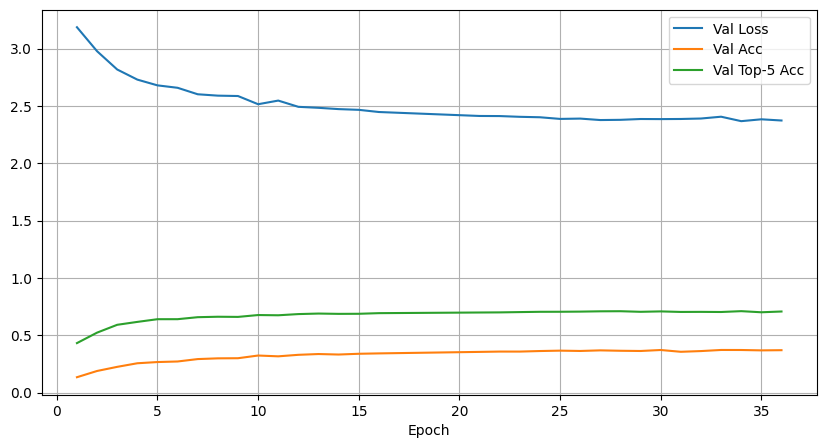

In [ ]:
epochs = [
    1,2,3,4,5,
    6,7,8,9,10,
    11,12,13,14,15,16,
    21,22,23,24,25,26,27,28,29,30,
    31,32,33,34,35,36
]
val_loss = [
    3.1873, 2.9779, 2.8184, 2.7302, 2.6800,
    2.6588, 2.6023, 2.5903, 2.5870, 2.5155,
    2.5472, 2.4927, 2.4841, 2.4728, 2.4665, 2.4475,
    2.4130, 2.4121, 2.4056, 2.4017, 2.3873, 2.3901, 2.3774,
    2.3793, 2.3864, 2.3856, 2.3867, 2.3907, 2.4065,
    2.3677, 2.3839, 2.3734
]
val_acc = [
    0.1335, 0.1880, 0.2240, 0.2553, 0.2659,
    0.2708, 0.2918, 0.2982, 0.2993, 0.3228,
    0.3158, 0.3290, 0.3358, 0.3315, 0.3381, 0.3414,
    0.3545, 0.3573, 0.3572, 0.3620, 0.3654, 0.3626, 0.3678,
    0.3643, 0.3624, 0.3710, 0.3554, 0.3617, 0.3713,
    0.3710, 0.3677, 0.3694
]
val_top5 = [
    0.4312, 0.5226, 0.5909, 0.6162, 0.6397,
    0.6399, 0.6573, 0.6612, 0.6598, 0.6760,
    0.6740, 0.6844, 0.6890, 0.6863, 0.6870, 0.6925,
    0.6982, 0.6992, 0.7018, 0.7043, 0.7046, 0.7059, 0.7086,
    0.7094, 0.7042, 0.7078, 0.7031, 0.7037, 0.7026,
    0.7099, 0.7002, 0.7069
]
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(epochs, val_loss, label="Val Loss")
plt.plot(epochs, val_acc, label="Val Acc")
plt.plot(epochs, val_top5, label="Val Top-5 Acc")
plt.xlabel("Epoch")
plt.legend()
plt.grid()
plt.show()


In [34]:
def compute_confusion_matrix(model, dataloader, idx_to_ph):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            inputs = batch['frames'].permute(0,2,1,3,4).to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=list(idx_to_ph.keys()))
    return cm

def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(16,14))
    sns.heatmap(cm, annot=False, cmap="viridis",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

idx_to_ph = {v: k for k, v in ph_to_idx.items()}
cm = compute_confusion_matrix(model, test_loader, idx_to_ph)
labels = [idx_to_ph[i] for i in range(len(idx_to_ph))]
plot_confusion_matrix(cm, labels)


KeyboardInterrupt: 

In [ ]:


model.eval()

num_clips = 5
clips = []
preds = []
labels = []

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        inputs = batch['frames']    # shape: [batch, time, channels, H, W] or similar
        targets = batch['label']   # labels tensor

        # Adjust input shape to match model expectation:
        # if model expects [batch, channels, time, H, W], permute inputs
        inputs = inputs.permute(0, 2, 1, 3, 4)  # [batch, channels, time, H, W]

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        # Now you can print or save the clips and their predicted and true labels
        for j in range(inputs.size(0)):
            print(f"Clip {i*inputs.size(0)+j}: True={targets[j].item()}, Predicted={preds[j].item()}")

        if i >= 4:  # just 5 batches/clips to demo
            break

# Show info and visualize first frames of the clips
for i in range(num_clips):
    clip = clips[i]  # shape: [channels, time, H, W], channels=1
    pred_label = idx_to_ph[preds[i].item()]
    true_label = idx_to_ph[labels[i].item()]

    print(f"Clip {i+1}: Predicted: {pred_label}, Actual: {true_label}")

    # Plot the first frame (time=0) of the clip
    frame = clip[0, 0].numpy()  # channels=1, time=0, shape=H x W
    plt.imshow(frame, cmap='gray')
    plt.title(f"Clip {i+1} - First frame\nPredicted: {pred_label}\nActual: {true_label}")
    plt.axis('off')
    plt.show()


Clip 0: True=8, Predicted=38
Clip 1: True=29, Predicted=20
Clip 2: True=28, Predicted=28
Clip 3: True=40, Predicted=29
Clip 4: True=40, Predicted=40
Clip 5: True=3, Predicted=10
Clip 6: True=5, Predicted=33
Clip 7: True=37, Predicted=2
Clip 8: True=20, Predicted=17
Clip 9: True=17, Predicted=23
Clip 10: True=17, Predicted=17
Clip 11: True=11, Predicted=2
Clip 12: True=22, Predicted=17
Clip 13: True=29, Predicted=29
Clip 14: True=22, Predicted=10
Clip 15: True=28, Predicted=23
Clip 16: True=24, Predicted=28
Clip 17: True=2, Predicted=2
Clip 18: True=22, Predicted=22
Clip 19: True=23, Predicted=17


IndexError: list index out of range

In [ ]:
for i, batch in enumerate(test_loader):
    print(type(batch))
    print(batch)
    break


<class 'dict'>
{'frames': tensor([[[[[0.0314, 0.0314, 0.0314,  ..., 0.0314, 0.0196, 0.0275],
           [0.0314, 0.0235, 0.0235,  ..., 0.0314, 0.0314, 0.0235],
           [0.0118, 0.0196, 0.0431,  ..., 0.0235, 0.0314, 0.0196],
           ...,
           [0.0314, 0.0314, 0.0314,  ..., 0.0510, 0.0627, 0.0353],
           [0.0275, 0.0275, 0.0078,  ..., 0.0471, 0.0510, 0.0353],
           [0.0157, 0.0353, 0.0275,  ..., 0.0510, 0.0471, 0.0353]]],


         [[[0.0275, 0.0275, 0.0235,  ..., 0.0471, 0.0392, 0.0235],
           [0.0235, 0.0235, 0.0157,  ..., 0.0549, 0.0510, 0.0471],
           [0.0314, 0.0235, 0.0118,  ..., 0.0588, 0.0392, 0.0627],
           ...,
           [0.0392, 0.0314, 0.0392,  ..., 0.0667, 0.0706, 0.0549],
           [0.0314, 0.0353, 0.0275,  ..., 0.0627, 0.0706, 0.0431],
           [0.0235, 0.0353, 0.0275,  ..., 0.0706, 0.0824, 0.0510]]],


         [[[0.0275, 0.0275, 0.0353,  ..., 0.0275, 0.0314, 0.0314],
           [0.0431, 0.0392, 0.0314,  ..., 0.0431, 0.0471, 0.015

In [ ]:
print(batch.keys())


dict_keys(['frames', 'phoneme', 'label', 'speaker'])


In [ ]:
num_samples = 5
clips = []
true_labels = []

# Get 5 samples (you might get them from multiple batches if batch size < 5)
for batch in test_loader:
    for i in range(len(batch['frames'])):
        clips.append(batch['frames'][i])   # shape likely [time, channels, H, W] or similar
        true_labels.append(batch['label'][i])
        if len(clips) == num_samples:
            break
    if len(clips) == num_samples:
        break

print(f"Collected {len(clips)} clips and labels")


Collected 5 clips and labels


In [ ]:
def clip_to_gif(clip_tensor, filename):
    # Assuming clip_tensor shape: [time, channels, H, W] or [time, H, W]
    # Convert to numpy, scale pixels [0,1] or [0,255]
    frames = clip_tensor.cpu().numpy()

    # If channels == 1, squeeze channel dimension
    if frames.shape[1] == 1:
        frames = frames[:, 0, :, :]  # [time, H, W]

    images = []
    for frame in frames:
        # Normalize to 0-255 uint8
        frame = (frame - frame.min()) / (frame.max() - frame.min() + 1e-5)
        frame_uint8 = (frame * 255).astype(np.uint8)
        images.append(frame_uint8)

    # Save gif
    imageio.mimsave(filename, images, duration=0.1)  # 0.1 sec per frame

# Create GIFs for all clips
for i, clip in enumerate(clips):
    clip_to_gif(clip, f'clip_{i}.gif')


In [27]:


# Assuming:
# clips = list of 5 tensors, each shape [time, channels, H, W]
# model = your trained model
# device = 'cuda' or 'cpu'

model.eval()
with torch.no_grad():
    # Stack clips into a batch: shape [5, time, channels, H, W]
    batch = torch.stack(clips)  # shape: [5, time, channels, H, W]

    # Permute to [batch, channels, time, H, W] as expected by model
    inputs = batch.permute(0, 2, 1, 3, 4).to(device)  # send to GPU if available

    # Forward pass
    outputs = model(inputs)  # outputs shape: [5, num_classes]

    # Apply softmax to get probabilities
    probs = F.softmax(outputs, dim=1)  # [5, num_classes]

    # Get top 5 predictions per clip
    top5_probs, top5_indices = torch.topk(probs, 5, dim=1)

    # Print results for each clip
    for i in range(len(clips)):
        print(f"Clip {i}:")
        for rank in range(5):
            idx = top5_indices[i, rank].item()
            prob = top5_probs[i, rank].item()
            print(f"  Top {rank+1}: Class {idx} (probability {prob:.4f})")


NameError: name 'model' is not defined

In [ ]:
# Example
for i in range(num_samples):
    print(f"Clip {i}: True label = {idx_to_ph[true_labels[i].item()]}")
    print("Top 5 predictions:")
    for rank in range(5):
        pred_idx = top5_indices[i, rank].item()
        pred_prob = top5_probs[i, rank].item()
        print(f"  {rank+1}: {idx_to_ph[pred_idx]} (prob {pred_prob:.3f})")
    print()


Clip 0: True label = d
Top 5 predictions:
  1: w (prob 0.256)
  2: l (prob 0.172)
  3: b (prob 0.145)
  4: ah (prob 0.054)
  5: d (prob 0.052)

Clip 1: True label = s
Top 5 predictions:
  1: k (prob 0.559)
  2: w (prob 0.215)
  3: g (prob 0.150)
  4: p (prob 0.018)
  5: uw (prob 0.013)

Clip 2: True label = r
Top 5 predictions:
  1: r (prob 0.447)
  2: er (prob 0.430)
  3: ih (prob 0.019)
  4: t (prob 0.010)
  5: d (prob 0.010)

Clip 3: True label = z
Top 5 predictions:
  1: s (prob 0.281)
  2: z (prob 0.219)
  3: ih (prob 0.133)
  4: t (prob 0.091)
  5: ah (prob 0.033)

Clip 4: True label = z
Top 5 predictions:
  1: z (prob 0.312)
  2: ih (prob 0.189)
  3: s (prob 0.138)
  4: jh (prob 0.093)
  5: d (prob 0.039)



In [ ]:

# clips: list of 5 tensors [time, channels, H, W]
# model: your trained model
# device: 'cuda' or 'cpu'
# idx_to_ph: dict mapping class index to phoneme name, e.g., {0: 'AH', 1: 'B', ...}

model.eval()
with torch.no_grad():
    batch = torch.stack(clips)  # shape: [5, time, channels, H, W]
    inputs = batch.permute(0, 2, 1, 3, 4).to(device)  # [batch, channels, time, H, W]

    outputs = model(inputs)  # [5, num_classes]
    probs = F.softmax(outputs, dim=1)

    top5_probs, top5_indices = torch.topk(probs, 5, dim=1)

    for i in range(len(clips)):
        print(f"Clip {i}:")
        true_idx = labels[i].item()  # assuming labels is a tensor with true labels for clips
        true_ph = idx_to_ph[true_idx]
        print(f"  True label: {true_ph} (class {true_idx})")

        for rank in range(5):
            idx = top5_indices[i, rank].item()
            prob = top5_probs[i, rank].item()
            ph = idx_to_ph[idx]
            print(f"  Top {rank+1}: {ph} (class {idx}, probability {prob:.4f})")


Clip 0:


IndexError: list index out of range

In [ ]:
print(model)


Simple3DCNN(
  (conv1): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (bn1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (bn2): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  (bn3): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): AdaptiveAvgPool3d(output_size=(1, 1, 1))
  (fc): Linear(in_features=64, out_features=42, bias=True)
)


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer_name = target_layer_name
        self.feature_maps = None
        self.gradients = None

        # Register hooks
        target_layer = dict([*self.model.named_modules()])[target_layer_name]
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.feature_maps = output.detach()

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, inputs, target_class):
        self.model.eval()

        inputs = inputs.requires_grad_()
        outputs = self.model(inputs)  # Forward pass

        if outputs.ndim == 1 or outputs.shape[0] == 1:
            score = outputs[0, target_class]
        else:
            score = outputs[0, target_class]

        self.model.zero_grad()
        score.backward(retain_graph=True)

        # Gradients and feature maps shape: [batch, channels, time, H, W]
        gradients = self.gradients[0]  # [C, T, H, W]
        fmap = self.feature_maps[0]    # [C, T, H, W]

        # Global average pooling on gradients over time and spatial dims
        weights = gradients.mean(dim=(1, 2, 3))  # [C]

        # Weighted sum of feature maps
        cam = torch.zeros(fmap.shape[1:], dtype=torch.float32)  # [T, H, W]
        for i, w in enumerate(weights):
            cam += w * fmap[i]

        # Apply ReLU and normalize
        cam = torch.relu(cam)
        cam -= cam.min()
        if cam.max() != 0:
            cam /= cam.max()

        return cam.cpu().numpy()  # [time, H, W]


In [ ]:
def overlay_heatmap_on_frame(frame, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    """
    frame: 2D numpy array or PIL image, grayscale or RGB
    heatmap: 2D numpy array with values in [0,1]
    alpha: transparency of heatmap overlay

    Returns: RGB image with heatmap overlay
    """
    if isinstance(frame, torch.Tensor):
        frame = frame.cpu().numpy()

    if frame.ndim == 2:  # grayscale to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    elif frame.shape[0] == 3:  # C,H,W to H,W,C
        frame = np.transpose(frame, (1, 2, 0))

    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(heatmap_color, alpha, frame, 1 - alpha, 0)
    return overlay


In [ ]:
inputs = inputs.permute(0, 2, 1, 3, 4)
outputs = model(inputs)

model.eval()
with torch.no_grad():
    outputs = model(inputs)
    probs = torch.softmax(outputs, dim=1)
    top5_prob, top5_idx = torch.topk(probs, 5)

pred_label = top5_idx[0, 0].item()  # top 1 predicted class index

gradcam = GradCAM(model, target_layer_name='fc')  # replace with your conv layer name

cam = gradcam.generate(inputs, target_class=pred_label)


RuntimeError: Given groups=1, weight of size [16, 1, 3, 3, 3], expected input[1, 10, 1, 64, 64] to have 1 channels, but got 10 channels instead

In [ ]:


# Assuming you have:
# clip: tensor of shape [channels, time, H, W]
# true_label: int (index)
# pred_label: int (index)
# idx_to_ph: dict mapping label indices to phoneme names

# Prepare clip for model: [1, channels, time, H, W]
inputs = clip.unsqueeze(0)

# Instantiate GradCAM
gradcam = GradCAM(model, target_layer_name='fc')  # Replace 'conv_layer' with your layer name

# Generate CAM heatmap
cam = gradcam.generate(inputs, target_class=pred_label)

# Plot some frames with heatmaps overlay
num_frames_to_show = min(5, cam.shape[0])  # e.g., show 5 frames max
fig, axes = plt.subplots(1, num_frames_to_show, figsize=(15, 3))

for i in range(num_frames_to_show):
    frame = clip[:, i].cpu().numpy()  # [channels, H, W], channels=1 for grayscale
    heatmap = cam[i]
    overlay = overlay_heatmap_on_frame(frame, heatmap)

    axes[i].imshow(overlay)
    axes[i].axis('off')
    if i == 0:
        axes[i].set_title(f'True: {idx_to_ph[true_label]}\nPred: {idx_to_ph[pred_label]}')
plt.show()


NameError: name 'pred_label' is not defined

# Analyzing phoneme length

In [ ]:
def collect_phoneme_durations(root_path, keep_sil=False):
    phoneme_durations = defaultdict(list)

    for speaker in sorted(os.listdir(root_path)):
        speaker_path = os.path.join(root_path, speaker, "trans")
        if not os.path.isdir(speaker_path):
            continue

        for fname in os.listdir(speaker_path):
            if not fname.endswith(".trans"):
                continue

            path = os.path.join(speaker_path, fname)

            with open(path, "r") as f:
                for line in f:
                    parts = line.strip().split(",")
                    if len(parts) < 3:
                        continue

                    start = float(parts[0])
                    end = float(parts[1])
                    phoneme = parts[2].strip()

                    if phoneme == "sil" and not keep_sil:
                        continue

                    duration = end - start
                    if duration > 0:
                        phoneme_durations[phoneme].append(duration)

    return phoneme_durations


In [ ]:


def phoneme_duration_stats(phoneme_durations):
    rows = []
    for ph, durs in phoneme_durations.items():
        rows.append({
            "phoneme": ph,
            "count": len(durs),
            "mean_duration": np.mean(durs),
            "median_duration": np.median(durs),
            "std_duration": np.std(durs),
        })

    return pd.DataFrame(rows).sort_values("mean_duration", ascending=False)


In [ ]:
root = f"{file_path}/USC-TIMIT/MRI/Data"
durations = collect_phoneme_durations(root)
df_stats = phoneme_duration_stats(durations)

print(df_stats.head(42))


   phoneme  count  mean_duration  median_duration  std_duration
0       ga    276       1.000000          1.00000      0.000000
32      aw    854       0.180401          0.18000      0.088924
40      sp   1099       0.168211          0.07000      0.430124
15      ay   2406       0.164621          0.16000      0.083274
34      oy    470       0.159657          0.15015      0.071160
30      aa   2476       0.149198          0.15000      0.078822
4       ey   2598       0.144800          0.13013      0.078692
31      ae   3702       0.142891          0.14000      0.093159
18      ow   1963       0.138968          0.13000      0.078283
27      ao   2655       0.126897          0.11000      0.082868
20      er   4438       0.114332          0.11000      0.070201
38      zh    158       0.110333          0.08004      0.090378
8       iy   4965       0.110175          0.10000      0.072481
22      eh   3058       0.105712          0.08008      0.069885
11      uw   2530       0.103940        

In [ ]:
# df_stats has 'mean_duration' and 'count' columns

weighted_sum = (df_stats['mean_duration'] * df_stats['count']).sum()
total_counts = df_stats['count'].sum()
global_mean_duration = weighted_sum / total_counts

print(f"Global mean phoneme duration (weighted): {global_mean_duration:.4f} seconds")


Global mean phoneme duration (weighted): 0.0834 seconds


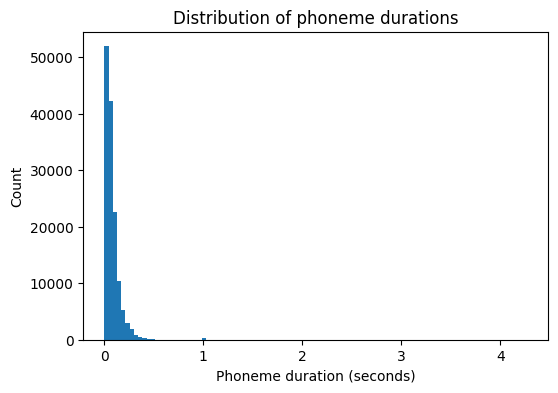

In [ ]:


all_durations = [d for durs in durations.values() for d in durs]

plt.figure(figsize=(6,4))
plt.hist(all_durations, bins=100)
plt.xlabel("Phoneme duration (seconds)")
plt.ylabel("Count")
plt.title("Distribution of phoneme durations")
plt.show()


In [ ]:


def plot_phoneme_boxplots(phoneme_durations, min_samples=50):
    """
    Creates box plots for phonemes with enough samples
    """
    phonemes = []
    data = []

    for ph, durations in sorted(phoneme_durations.items()):
        if len(durations) >= min_samples:
            phonemes.append(ph)
            data.append(durations)

    plt.figure(figsize=(18, 6))
    plt.boxplot(data, labels=phonemes, showfliers=False)
    plt.xticks(rotation=90)
    plt.ylabel("Duration (seconds)")
    plt.title("Phoneme Duration Distributions")
    plt.tight_layout()
    plt.show()


/var/folders/yd/316cj0rs5rx70pqb55y4m36c0000gn/T/ipykernel_69523/362262349.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=phonemes, showfliers=False)


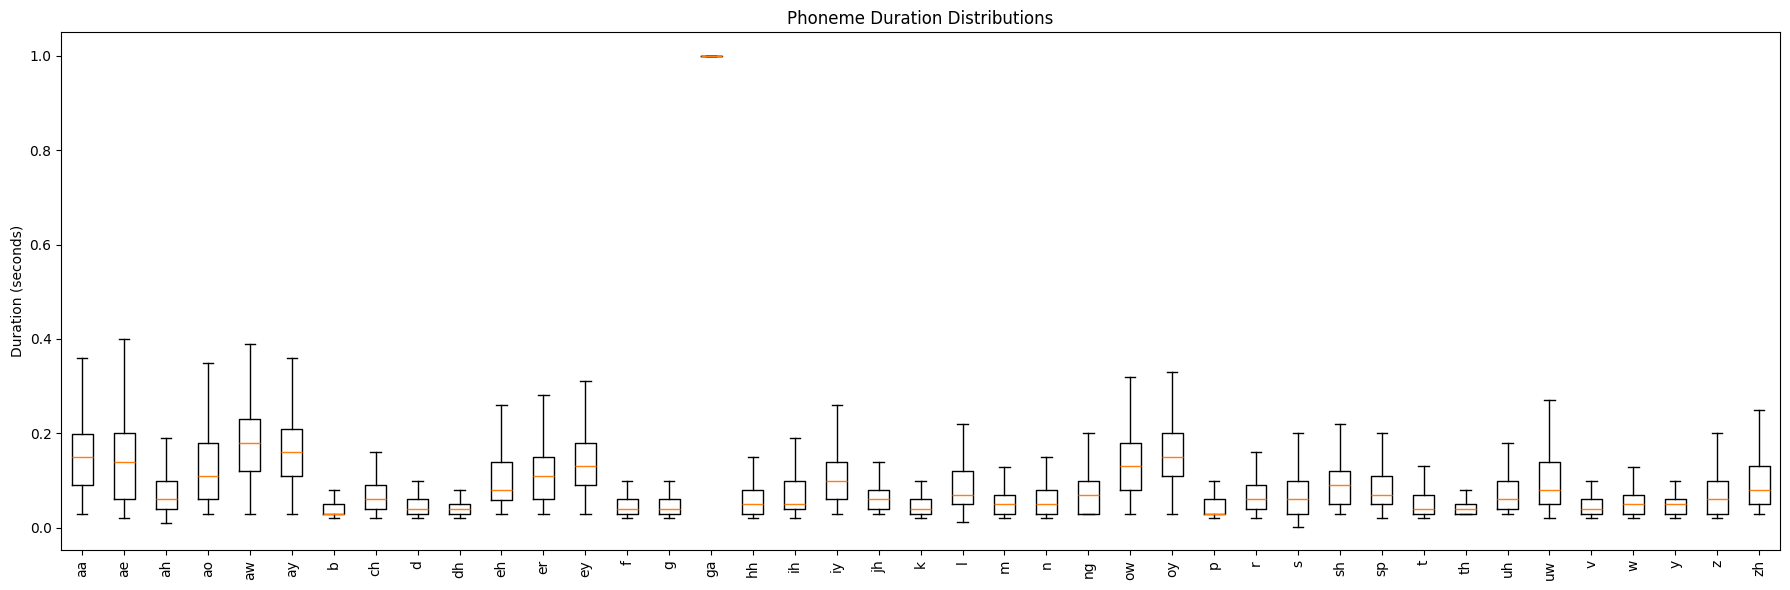

In [ ]:
root = f"{file_path}/USC-TIMIT/MRI/Data"

phoneme_durations = collect_phoneme_durations(root, keep_sil=False)

plot_phoneme_boxplots(phoneme_durations, min_samples=100)


# Precision, recall per phoneme

In [ ]:
# Load checkpoint
checkpoint = torch.load("checkpoint-9frames.pth.tar", map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["frames"]  # shape: [B, T, C, H, W]
        labels = batch["label"]

        # Model expects: [B, C, T, H, W]
        inputs = inputs.permute(0, 2, 1, 3, 4)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())


In [ ]:
ckpt = torch.load("checkpoint.pth.tar", map_location="cpu")
print(ckpt.keys())


dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_val_acc'])


In [ ]:
# Compute per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds,
    labels=list(range(len(df_stats))),  # ensure correct order
    zero_division=0                    # avoid NaN
)

df_metrics = pd.DataFrame({
    "phoneme": df_stats["phoneme"].tolist(),
    "precision9": precision,
    "recall9": recall,
    "f19": f1,
    "support9": support
})


In [ ]:
df_full2 = df_full.merge(df_metrics, on="phoneme", how="left")


In [ ]:
print(df_full2.head(42))


   phoneme  count  mean_duration  median_duration  std_duration  precision  \
0       ga    276       1.000000          1.00000      0.000000   0.320513   
1       aw    854       0.180401          0.18000      0.088924   0.470588   
2       sp   1099       0.168211          0.07000      0.430124   0.255300   
3       ay   2406       0.164621          0.16000      0.083274   0.468750   
4       oy    470       0.159657          0.15015      0.071160   0.593750   
5       aa   2476       0.149198          0.15000      0.078822   0.383387   
6       ey   2598       0.144800          0.13013      0.078692   0.398496   
7       ae   3702       0.142891          0.14000      0.093159   0.270270   
8       ow   1963       0.138968          0.13000      0.078283   0.309278   
9       ao   2655       0.126897          0.11000      0.082868   0.445783   
10      er   4438       0.114332          0.11000      0.070201   0.324561   
11      zh    158       0.110333          0.08004      0.090378 

In [ ]:
# Columns you want to rename
cols_to_rename = ["precision", "recall", "f1-score", "support"]

# Create a mapping: {"precision": "precision5", ...}
rename_map = {col: col + "5" for col in cols_to_rename}

# Apply rename
df_stats = df_stats.rename(columns=rename_map)

df_stats.head()


,phoneme,count,mean_duration,median_duration,std_duration
0,ga,276,1.000000,1.00000,0.000000
32,aw,854,0.180401,0.18000,0.088924
40,sp,1099,0.168211,0.07000,0.430124
15,ay,2406,0.164621,0.16000,0.083274
34,oy,470,0.159657,0.15015,0.071160


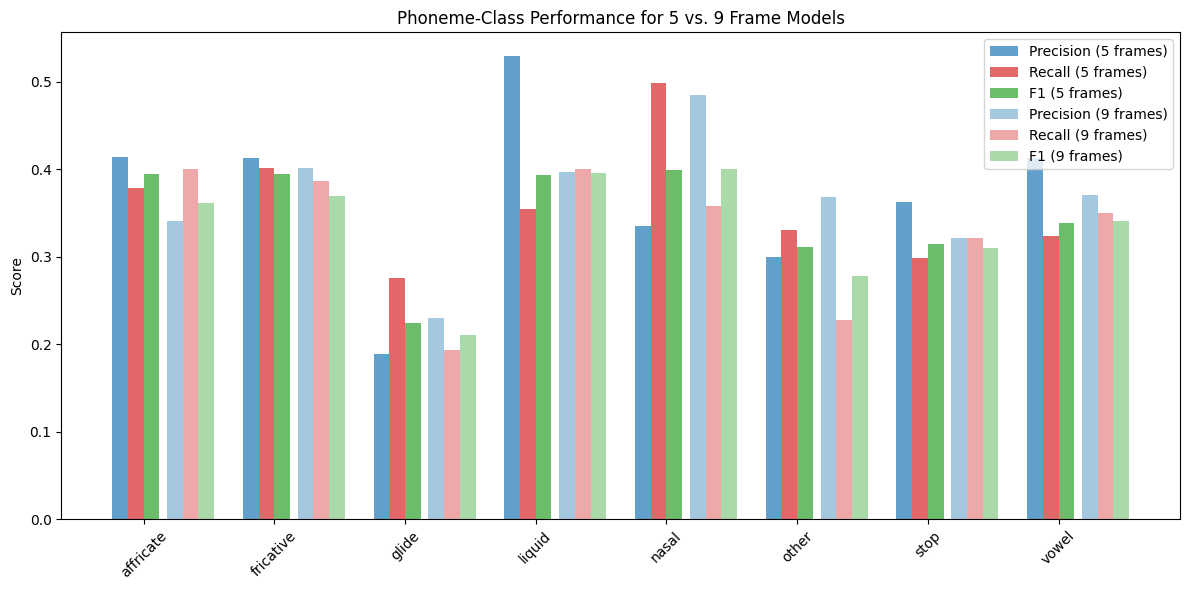

In [25]:

# Data
classes = ["affricate", "fricative", "glide", "liquid", "nasal", "other", "stop", "vowel"]

precision_5 = [0.414, 0.413, 0.189, 0.530, 0.335, 0.300, 0.363, 0.413]
recall_5    = [0.378, 0.401, 0.276, 0.355, 0.498, 0.331, 0.299, 0.324]
f1_5        = [0.395, 0.394, 0.224, 0.393, 0.399, 0.311, 0.314, 0.338]

precision_9 = [0.341, 0.401, 0.230, 0.397, 0.485, 0.368, 0.321, 0.370]
recall_9    = [0.400, 0.386, 0.193, 0.400, 0.358, 0.228, 0.321, 0.350]
f1_9        = [0.361, 0.369, 0.210, 0.396, 0.400, 0.278, 0.310, 0.341]

print{f"precision5 mean is "}
x = np.arange(len(classes))
w = 0.12

fig, ax = plt.subplots(figsize=(12, 6))

# Bars for 5-frame model
ax.bar(x - 1.5*w, precision_5, width=w, label="Precision (5 frames)")
ax.bar(x - 0.5*w, recall_5,    width=w, label="Recall (5 frames)")
ax.bar(x + 0.5*w, f1_5,        width=w, label="F1 (5 frames)")

# Bars for 9-frame model
ax.bar(x + 1.5*w, precision_9, width=w, label="Precision (9 frames)")
ax.bar(x + 2.5*w, recall_9,    width=w, label="Recall (9 frames)")
ax.bar(x + 3.5*w, f1_9,        width=w, label="F1 (9 frames)")

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.set_ylabel("Score")
ax.set_title("Phoneme-Class Performance for 5 vs. 9 Frame Models")
ax.legend()
plt.tight_layout()
plt.show()
